In [2]:
# 94 is 90 degrees, 95 is 75 degrees, 96 is 60 degrees, 97 and 98 is 45 degrees, 99 is 30 degrees

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [4]:
#####################################################################################################

class CosmicWatchMeasurement:
    field_idx = {
        3 : 'times',
        6 : 'energies',
        7 : 'temperatures',
        8 : 'pressures',
        9 : 'dead_times',
        10 : 'coincident'
    }

    def __init__(self,
                 data_file,
                 only_coincident=True,
                 energy_cut=None):
        
        self._read_data(data_file)
        self.temperature_avg, self.temperature_std, self.temperature_max, self.temperature_min = self._get_average_param('temperatures')
        self.pressure_avg, self.pressure_std, self.pressure_max, self.pressure_min = self._get_average_param('pressures')

        if only_coincident:
            self._filter_coincident()
        if energy_cut is not None:
            self._filter_energy(energy_cut)

        self._get_rate()

    def _read_data(self,data_file):
        data = {
            field : [] for idx,field in self.field_idx.items()
        }
        with open(data_file, 'r') as f:
            for line in f.readlines():
            
                if line.startswith('#'):
                    continue
                line_data = line.split()
                for idx, field in self.field_idx.items():
                    data[field].append(float(line_data[idx]))

        for field in data:
            setattr(self,field,np.array(data[field]))

        self.total_time = self.times[-1]*1e-3

        self.dead_times = np.cumsum(self.dead_times)*1e-6
        self.times = self.times*1e-3 - self.dead_times

        self.live_time = self.times[-1]

    def _filter_coincident(self):
        mask = self.coincident == 1
        for field in self.field_idx.values():
            setattr(self,field,getattr(self,field)[mask])

    def _filter_energy(self, energy_cut):
        mask = self.energies > energy_cut
        for field in self.field_idx.values():
            setattr(self,field,getattr(self,field)[mask])

    def _get_rate(self):
        self.counts = self.times.size
        interval = self.times[-1] - self.times[0]

        self.rate = (self.counts-1) / interval * 1e3
        self.rate_err = np.sqrt(self.counts-1) / interval * 1e3

        self.rate_sys_err = (5 * self.total_time/3600/24) / interval * 1e3

    def _get_average_param(self,param):
        param_avg = np.mean(getattr(self, param))
        param_std = np.std(getattr(self, param))

        param_max = np.max(getattr(self, param))
        param_min = np.min(getattr(self, param))

        return param_avg, param_std, param_max, param_min

1.1013804050925926
90056.86335200001
453
5.0528390212459


Text(0, 0.5, 'Counts')

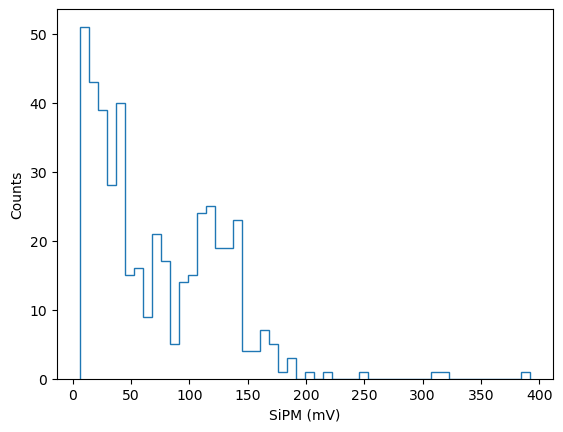

In [5]:
deg90_cosmic_watch_data = CosmicWatchMeasurement(data_file="angular_dist\\FileC094.txt")
deg90_cosmic_watch_data._get_rate()
print(deg90_cosmic_watch_data.total_time/3600/24)
print(deg90_cosmic_watch_data.live_time)
print(deg90_cosmic_watch_data.counts)
print(deg90_cosmic_watch_data.rate)


plt.hist(deg90_cosmic_watch_data.energies, bins=50, histtype='step', label='90 degrees')
plt.xlabel('SiPM (mV)')
plt.ylabel('Counts')

1.1682793634259259
95516.214733
449
4.707229389328063


Text(0, 0.5, 'Counts')

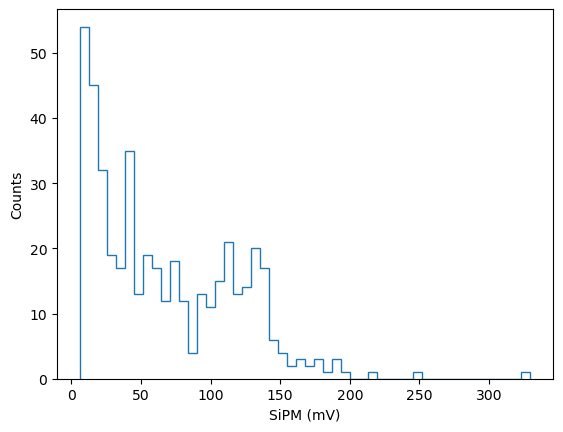

In [6]:
deg75_cosmic_watch_data = CosmicWatchMeasurement(data_file="angular_dist\\FileC095.txt")
deg75_cosmic_watch_data._get_rate()
print(deg75_cosmic_watch_data.total_time/3600/24)
print(deg75_cosmic_watch_data.live_time)
print(deg75_cosmic_watch_data.counts)
print(deg75_cosmic_watch_data.rate)

plt.hist(deg75_cosmic_watch_data.energies, bins=50, histtype='step', label='75 degrees')
plt.xlabel('SiPM (mV)')
plt.ylabel('Counts')

2.3181620138888888
189528.825285
865
4.565831820151853


Text(0, 0.5, 'Counts')

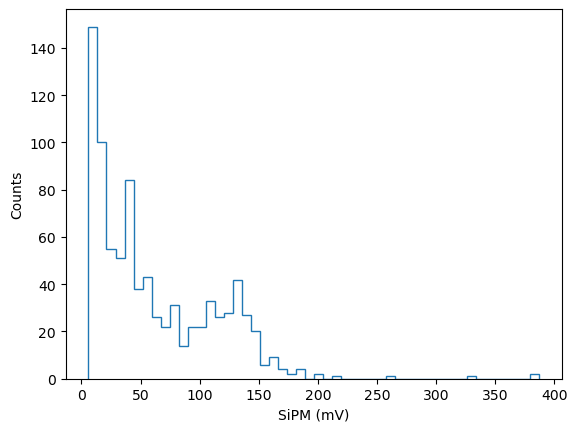

In [7]:
deg60_cosmic_watch_data = CosmicWatchMeasurement(data_file="angular_dist\\FileC096.txt")
deg60_cosmic_watch_data._get_rate()
print(deg60_cosmic_watch_data.total_time/3600/24)
print(deg60_cosmic_watch_data.live_time)
print(deg60_cosmic_watch_data.counts)
print(deg60_cosmic_watch_data.rate)

plt.hist(deg60_cosmic_watch_data.energies, bins=50, histtype='step', label='60 degrees')
plt.xlabel('SiPM (mV)')
plt.ylabel('Counts')

In [8]:
deg45_cosmic_watch_data1 = CosmicWatchMeasurement(data_file="angular_dist\\FileC097.txt") 
deg45_cosmic_watch_data2 = CosmicWatchMeasurement(data_file="angular_dist\\FileC098.txt")
deg45_cosmic_watch_data1._get_rate()
# print(deg45_cosmic_watch_data.total_time/3600/24)
# print(deg45_cosmic_watch_data.live_time)
# print(deg45_cosmic_watch_data.counts)
# print(deg45_cosmic_watch_data.rate)

# plt.hist(deg45_cosmic_watch_data.energies, bins=50, histtype='step', label='45 degrees')
# plt.xlabel('SiPM (mV)')
# plt.ylabel('Counts')

2.1375999421296297
175085.618155
611
3.4867163416711544


Text(0, 0.5, 'Counts')

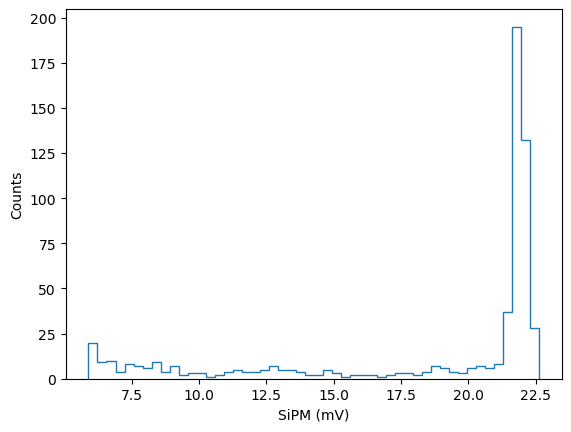

In [9]:
deg30_cosmic_watch_data = CosmicWatchMeasurement(data_file="angular_dist\\FileC099.txt")
deg30_cosmic_watch_data._get_rate()
print(deg30_cosmic_watch_data.total_time/3600/24)
print(deg30_cosmic_watch_data.live_time)
print(deg30_cosmic_watch_data.counts)
print(deg30_cosmic_watch_data.rate)
    
plt.hist(deg30_cosmic_watch_data.energies, bins=50, histtype='step', label='30 degrees')
plt.xlabel('SiPM (mV)')
plt.ylabel('Counts')

NameError: name 'deg45_cosmic_watch_data' is not defined

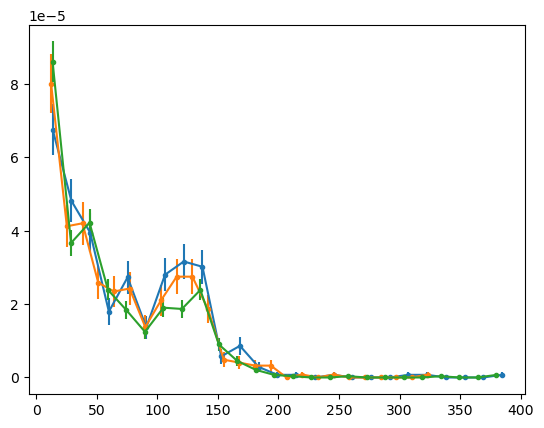

In [10]:
counts, bins = np.histogram(deg90_cosmic_watch_data.energies, bins=25)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
# plt.plot(bin_centers, counts/deg90_cosmic_watch_data.live_time/(bins[1:] - bins[:-1]), label='90 degrees')
plt.errorbar(bin_centers, counts/deg90_cosmic_watch_data.live_time/(bins[1:] - bins[:-1]),
             np.sqrt(counts)/deg90_cosmic_watch_data.live_time/(bins[1:] - bins[:-1]),
             fmt='.-', label='90 degrees')

counts, bins = np.histogram(deg75_cosmic_watch_data.energies, bins=25)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
# plt.plot(bin_centers, counts/deg75_cosmic_watch_data.live_time/(bins[1:] - bins[:-1]), label='75 degrees')
plt.errorbar(bin_centers, counts/deg75_cosmic_watch_data.live_time/(bins[1:] - bins[:-1]),
             np.sqrt(counts)/deg75_cosmic_watch_data.live_time/(bins[1:] - bins[:-1]),
             fmt='.-', label='75 degrees')

counts, bins = np.histogram(deg60_cosmic_watch_data.energies, bins=25)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
# plt.plot(bin_centers, counts/deg60_cosmic_watch_data.live_time/(bins[1:] - bins[:-1]), label='60 degrees')
plt.errorbar(bin_centers, counts/deg60_cosmic_watch_data.live_time/(bins[1:] - bins[:-1]),
             np.sqrt(counts)/deg60_cosmic_watch_data.live_time/(bins[1:] - bins[:-1]),
             fmt='.-', label ='60 degrees')

counts, bins = np.histogram(deg45_cosmic_watch_data.energies, bins=25)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
# plt.plot(bin_centers, counts/deg45_cosmic_watch_data.live_time/(bins[1:] - bins[:-1]), label='45 degrees')
plt.errorbar(bin_centers, counts/deg45_cosmic_watch_data.live_time/(bins[1:] - bins[:-1]),
             np.sqrt(counts)/deg45_cosmic_watch_data.live_time/(bins[1:] - bins[:-1]),
             fmt='.-', label='45 degrees')

counts, bin = np.histogram(cosmic_watch_data.energies, bins=25)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
# plt.plot(bin_centers, counts/cosmic_watch_data.live_time/(bins[1:] - bins[:-1]), label='Cosmic Watch')

plt.vlines(90, 0, 10e-5, color='gray', linestyle='dashed')
plt.legend()
plt.xlabel('SiPM (mV)')
plt.ylabel('Count Rate')

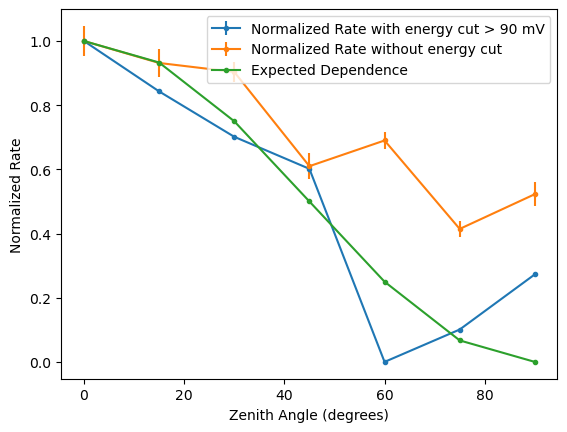

In [11]:
files = ["FileC094.txt","FileC095.txt","FileC096.txt","FileC097.txt","FileC099.txt","FileC003.txt","FileC001.txt"]
angles = [0,15,30,45, 60, 75,90] # 90 - angle we record
high_energy_rates = []
high_energy_counts = []
counts = []
rates = []
rate_errors = []
times = []
for angle,file in zip(angles,files):
    cosmic_watch_data = CosmicWatchMeasurement(data_file="angular_dist\\" + file)
    high_energy = [i for i in cosmic_watch_data.energies if i > 90]
    high_energy_rate = len(high_energy) / cosmic_watch_data.live_time * 1e3
    high_energy_counts = len(high_energy)
    high_energy_rates.append(high_energy_rate)

    counts.append(cosmic_watch_data.counts)
    rates.append(cosmic_watch_data.rate)
    rate_errors.append(cosmic_watch_data.rate_err)
    times.append(cosmic_watch_data.live_time)

exp_dep = [math.cos(math.radians(angle))**2 for angle in angles]


plt.errorbar(angles,high_energy_rates/np.max(high_energy_rates), np.sqrt(high_energy_counts)/np.max(high_energy_rates)/times,fmt = '.-', label = 'Normalized Rate with energy cut > 90 mV')
plt.errorbar(angles,rates/np.max(rates), rate_errors/np.max(rates),fmt = '.-', label = 'Normalized Rate without energy cut')
plt.errorbar(angles,exp_dep, fmt = '.-', label = 'Expected Dependence')
plt.xlabel('Zenith Angle (degrees)') 
plt.ylabel('Normalized Rate')
plt.legend()